In [1]:
import pandas as pd
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
home_dir = '/content/gdrive/MyDrive/KB RiR/Publicaties/DutchDraCor_gender/'
data_folder = home_dir + 'data'
character_data = data_folder + '/character_data/'
play_data = data_folder + '/play_data/'

os.listdir(play_data)

['plays_df_fre.csv',
 'plays_df_ger.csv',
 'plays_df_cal.csv',
 'plays_df_dutch.csv',
 'plays_df_ita.csv',
 'plays_df_eng.csv']

In [4]:
fre_play_data = pd.read_csv(play_data + 'plays_df_fre.csv', sep=";")
eng_play_data = pd.read_csv(play_data + 'plays_df_eng.csv', sep=";")
ger_play_data = pd.read_csv(play_data + 'plays_df_ger.csv', sep=";")
cal_play_data = pd.read_csv(play_data + 'plays_df_cal.csv', sep=";")
dutch_play_data = pd.read_csv(play_data + 'plays_df_dutch.csv', sep=";")
ita_play_data = pd.read_csv(play_data + 'plays_df_ita.csv', sep=";")

In [5]:
fre_character_data = pd.read_csv(character_data + 'character_df_fre.csv', sep=";")
eng_character_data = pd.read_csv(character_data + 'character_df_eng.csv', sep=";")
ger_character_data = pd.read_csv(character_data + 'character_df_ger.csv', sep=";")
cal_character_data = pd.read_csv(character_data + 'character_df_cal.csv', sep=";")
dutch_character_data = pd.read_csv(character_data + 'character_df_dutch.csv', sep=";")
ita_character_data = pd.read_csv(character_data + 'character_df_ita.csv', sep=";")

In [6]:
merged_character_df = pd.concat([fre_character_data, eng_character_data, ger_character_data, cal_character_data, dutch_character_data, ita_character_data])
merged_character_df.head()

,Unnamed: 0,play_id,corpus,character_id,genre,name,gender,acts,scenes,speech turns,...,act 7,act 8,act 9,scenes (rel),speech turns (rel),lines (rel),degree (rel),female edges,male edges,betweenness
0,0,fre000001,fre,argelie,unknown,Argélie,FEMALE,4,12,51,...,0.0,0.0,0.0,0.41,0.20,0.25,0.71,2,3,0.03
1,1,fre000001,fre,clytie,unknown,Clytie,FEMALE,3,4,13,...,0.0,0.0,0.0,0.14,0.05,0.03,0.71,2,2,0.07
2,2,fre000001,fre,timagene,unknown,Timagene,MALE,4,6,28,...,0.0,0.0,0.0,0.21,0.11,0.10,0.57,0,1,0.00
3,3,fre000001,fre,phoenix,unknown,Phoenix,MALE,5,11,38,...,0.0,0.0,0.0,0.38,0.15,0.20,0.86,1,1,0.13
4,4,fre000001,fre,ismene,unknown,Ismene,FEMALE,5,19,85,...,0.0,0.0,0.0,0.66,0.33,0.31,1.00,1,1,0.29


In [7]:
merged_df = pd.concat([fre_play_data, eng_play_data, ger_play_data, cal_play_data, dutch_play_data, ita_play_data])
merged_df.head()

,Unnamed: 0,play_id,corpus,author,title,genre,year,characters,male,female,%_male_chars,%_female_chars,%_female_lines,acts,scenes,speech_turns,lines,mean_sp_length,density,%_male_lines
0,fre000001,fre000001,fre,Gaspard Abeille,"Argélie, Reine de Thessalie",unknown,1674.0,8,4,4,0.50,0.50,0.60,5,29,254,1900,7.48,0.61,0.39
1,fre000002,fre000002,fre,Gaspard Abeille,Coriolan,unknown,1676.0,7,3,3,0.43,0.43,0.24,0,23,243,1733,7.13,0.57,0.56
2,fre000003,fre000003,fre,Gaspard Abeille,Lyncée,unknown,1681.0,7,4,3,0.57,0.43,0.52,5,26,213,1563,7.34,0.62,0.48
3,fre000005,fre000005,fre,Jean Dumas d'Aigueberre,L'Avare Amoureux,unknown,1781.0,8,4,3,0.50,0.38,0.46,1,22,306,815,2.66,0.61,0.54
4,fre000006,fre000006,fre,Jean Dumas d'Aigueberre,Pan et Doris Pastorale,unknown,1729.0,9,3,0,0.33,0.00,0.00,1,7,60,240,4.00,0.83,0.63


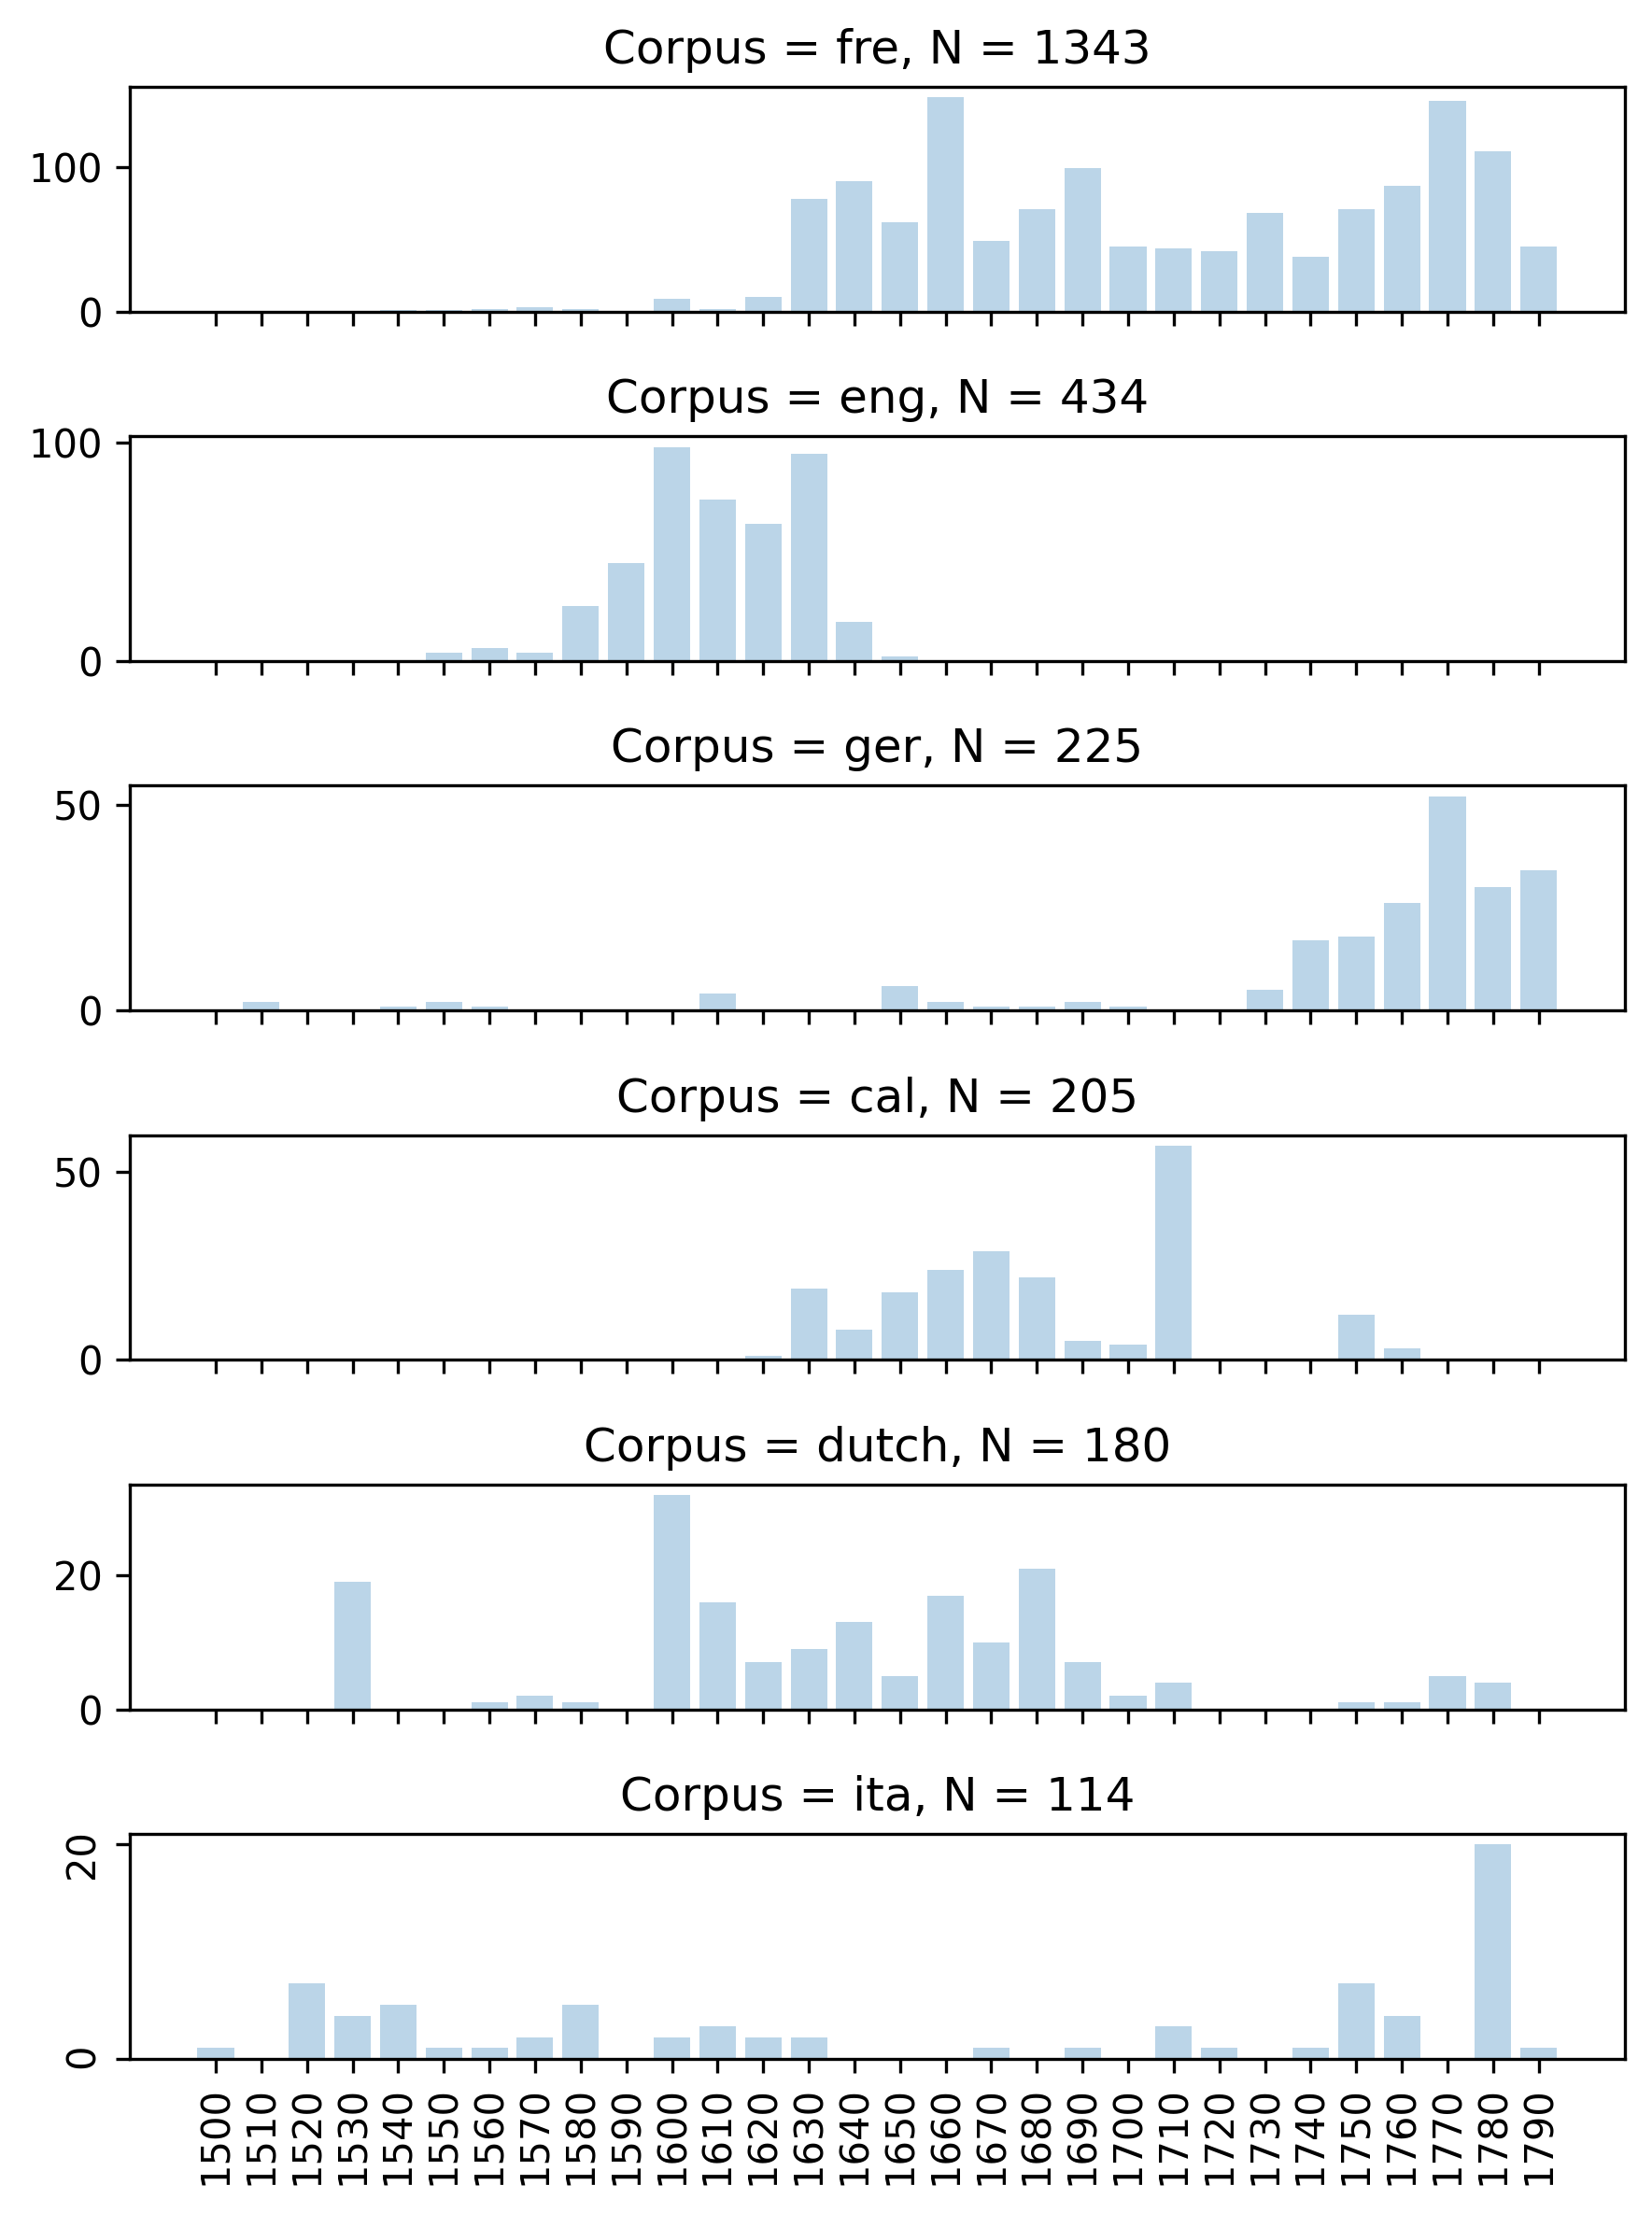

In [ ]:
decades = [str(decade) + "0" for decade in range(150,180)]

dataframes = [fre_play_data, eng_play_data, ger_play_data, cal_play_data, dutch_play_data, ita_play_data]
fig, axs = plt.subplots(6, sharex=True, figsize=(6, 8), dpi=300)
df_counter = 0

for dataframe in dataframes:
  corpus = dataframe.corpus.unique()[0]

  histogram = {}
  for decade in decades:
    histogram[decade] = 0

  for year in dataframe["year"].tolist():
    #print(year)
    if year != None:
      decade = str(year)[0:3] + "0"
      if decade != "nan0" and decade != 'unk0' and int(decade) < 1800:
        histogram[decade] += 1

  x_labels = list(histogram.keys())
  y_labels = list(histogram.values())

  axs[df_counter].bar(x_labels, y_labels, width=0.8, bottom=None, align='center', color="#BBD5E8", data=None)
  axs[df_counter].set_title('Corpus =' + " " + corpus + "" + (", N = ") + str(len(dataframe)))

  df_counter += 1

axs[5].set_xticks(x_labels, minor=True)
axs[5].tick_params(labelrotation=90)

fig.tight_layout()
plt.savefig(home_dir + "Figuren/" + "plays_per_decade.png", bbox_inches='tight') #uncomment to save the image


In [ ]:
independent_var = 'characters'
print(len(merged_character_df[merged_character_df.corpus == 'fre']))
print(len(merged_character_df[merged_character_df.corpus == 'eng']))
print(len(merged_character_df[merged_character_df.corpus == 'ger']))
print(len(merged_character_df[merged_character_df.corpus == 'cal']))
print(len(merged_character_df[merged_character_df.corpus == 'dutch']))
print(len(merged_character_df[merged_character_df.corpus == 'ita']))


13718
7124
3285
5916
2122
1085


In [ ]:
independent_var = 'speech_turns'

print(merged_df[merged_df.corpus == 'fre'][independent_var].sum(),
merged_df[merged_df.corpus == 'eng'][independent_var].sum(),
merged_df[merged_df.corpus == 'ger'][independent_var].sum(),
merged_df[merged_df.corpus == 'cal'][independent_var].sum(),
merged_df[merged_df.corpus == 'dutch'][independent_var].sum(),
merged_df[merged_df.corpus == 'ita'][independent_var].sum())

399440 310920 124141 121382 60021 62992


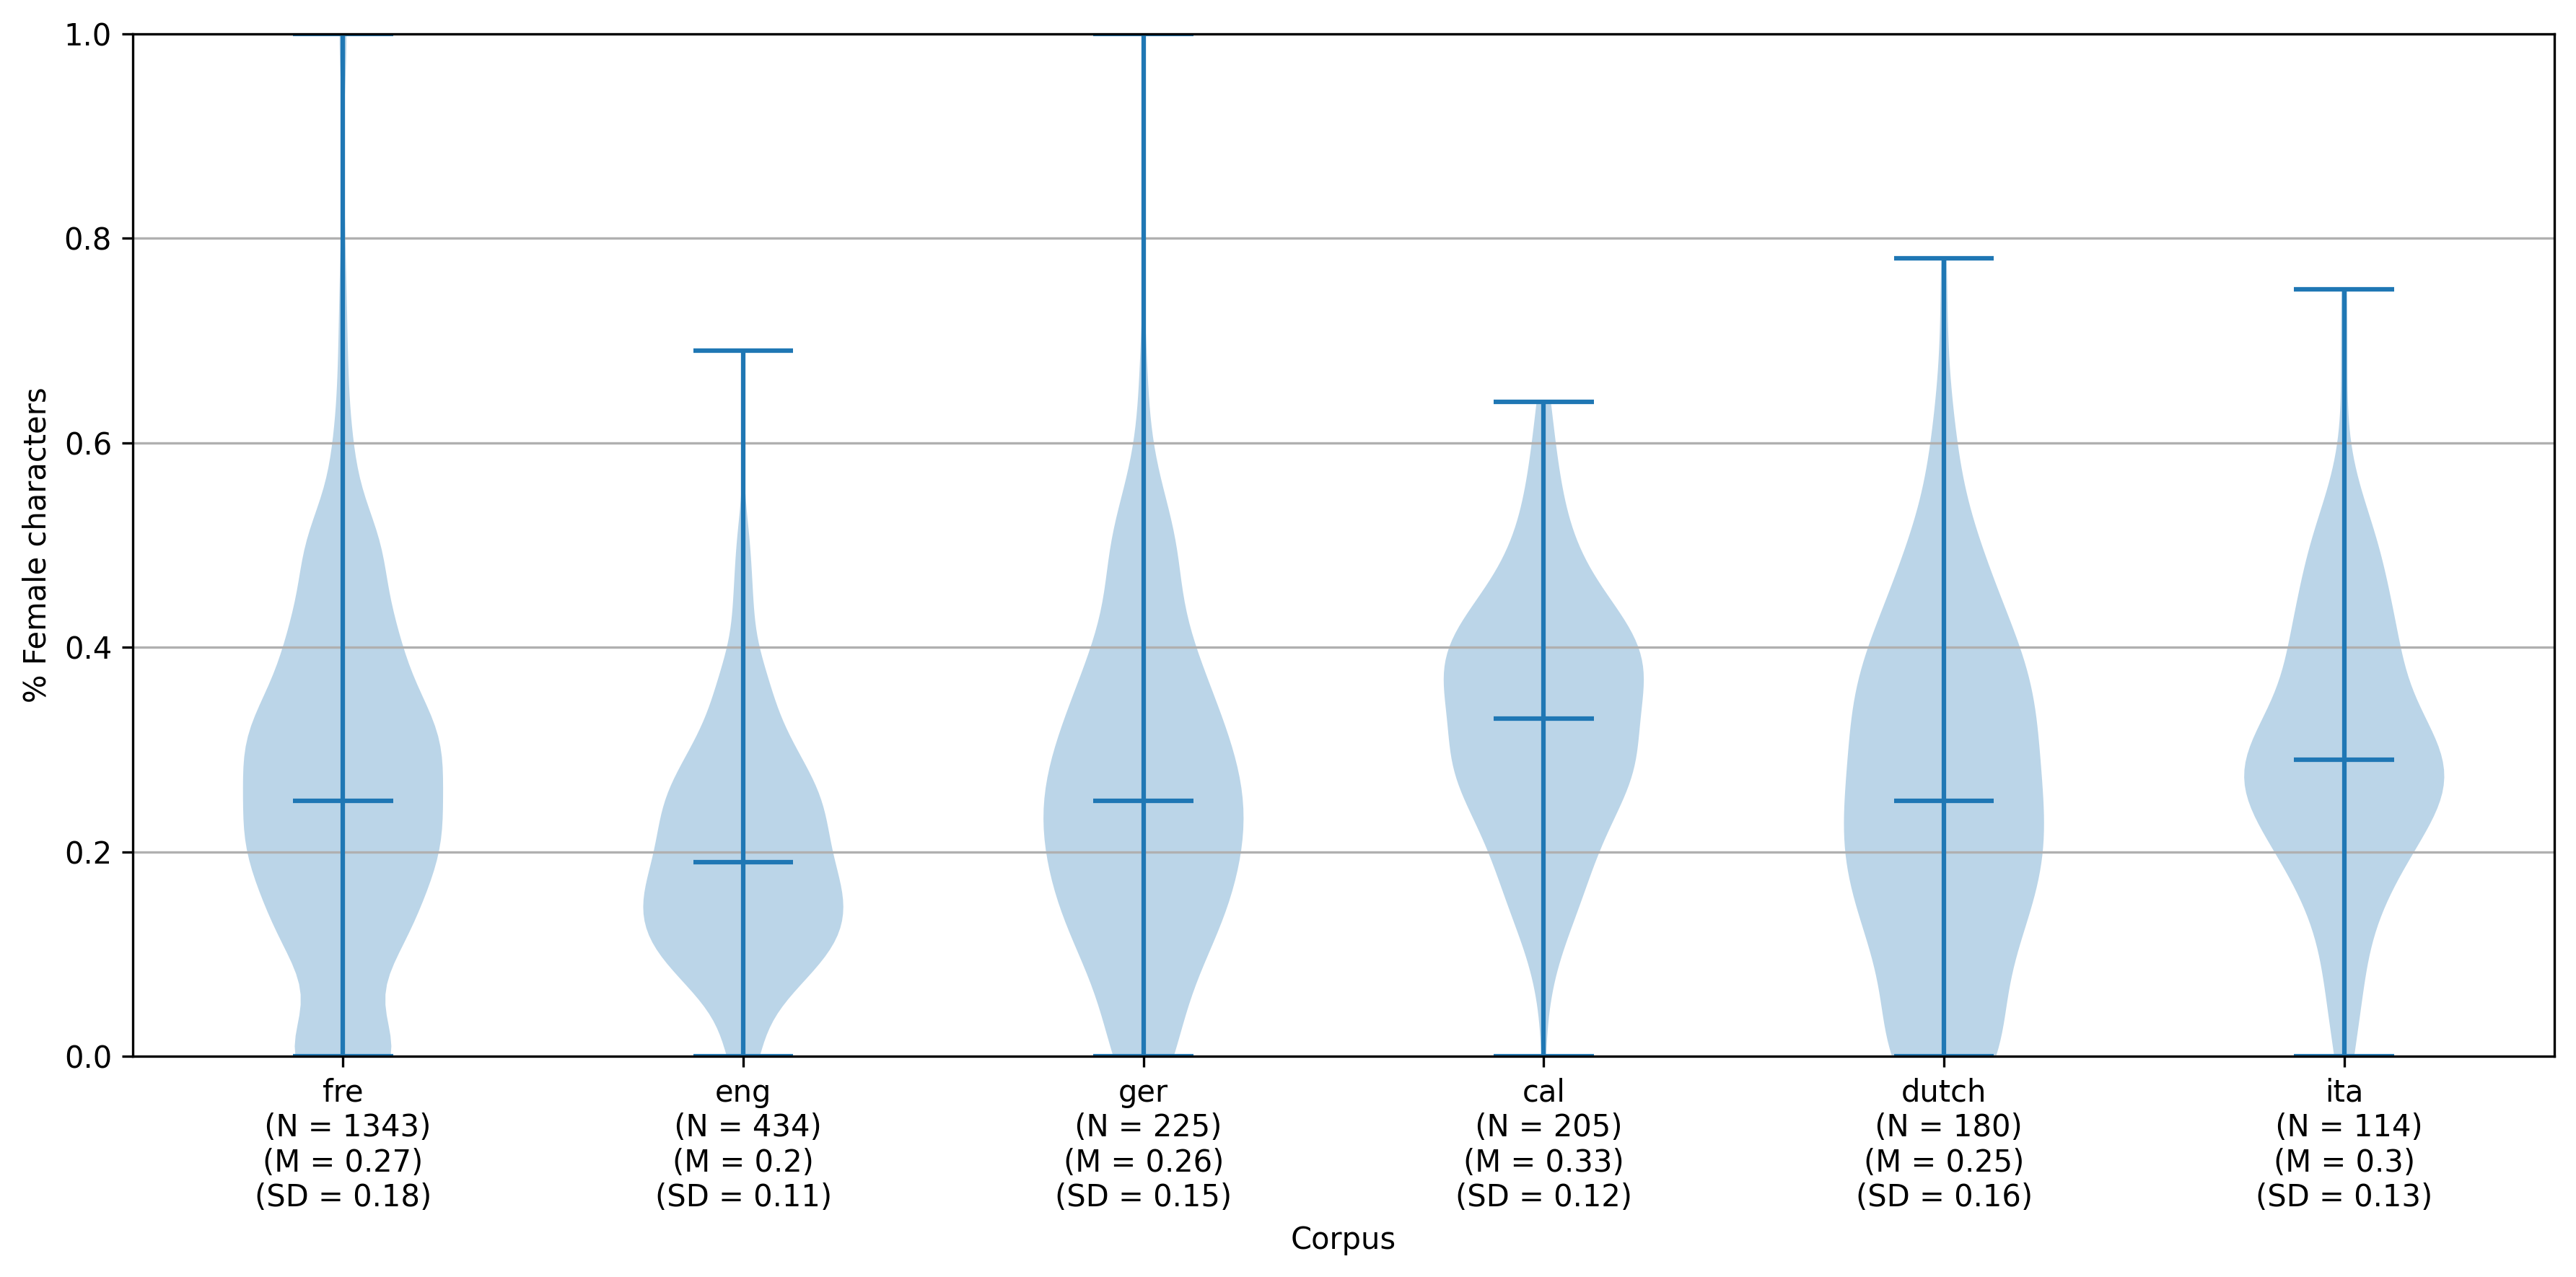

In [52]:
independent_var = "%_female_chars"

dataframes = [fre_play_data, eng_play_data, ger_play_data, cal_play_data, dutch_play_data, ita_play_data]

corpora = ["fre", "eng", "ger", "cal", "dutch", "ita"]
means = [merged_df[merged_df.corpus == corpus][independent_var].mean() for corpus in corpora]
stdvs = [merged_df[merged_df.corpus == corpus][independent_var].std() for corpus in corpora]

x_labels = [str(corpora[i] + "\n (N = " + str(len(merged_df[merged_df.corpus == corpora[i]])) + ")\n(M = " + str(round(means[i],2)) + ")\n(SD = " + str(round(stdvs[i],2)) + ")") for i in range(0,6)]

fig, axes = plt.subplots(figsize=(12, 6), dpi=300)

axes.violinplot(dataset = [merged_df[merged_df.corpus == 'fre'][independent_var].values,
                           merged_df[merged_df.corpus == 'eng'][independent_var].values,
                           merged_df[merged_df.corpus == 'ger'][independent_var].values,
                           merged_df[merged_df.corpus == 'cal'][independent_var].values,
                           merged_df[merged_df.corpus == 'dutch'][independent_var].values,
                           merged_df[merged_df.corpus == 'ita'][independent_var].values ], showmedians=True )



merged_df.groupby(['corpus'])[independent_var].median()

#axes.yaxis.grid(True)
axes.set_xlabel('Corpus')
axes.yaxis.grid(True)
axes.set_xticks([1,2,3,4,5,6], labels=x_labels)
axes.set_ylim(0,1)
axes.set_ylabel('% Female characters')

#plt.show()

fig.tight_layout()
plt.savefig(home_dir + "Figuren/" + "%_female_chars_per_corpus.png", bbox_inches='tight') #uncomment to save the image

<Figure size 900x1200 with 0 Axes>

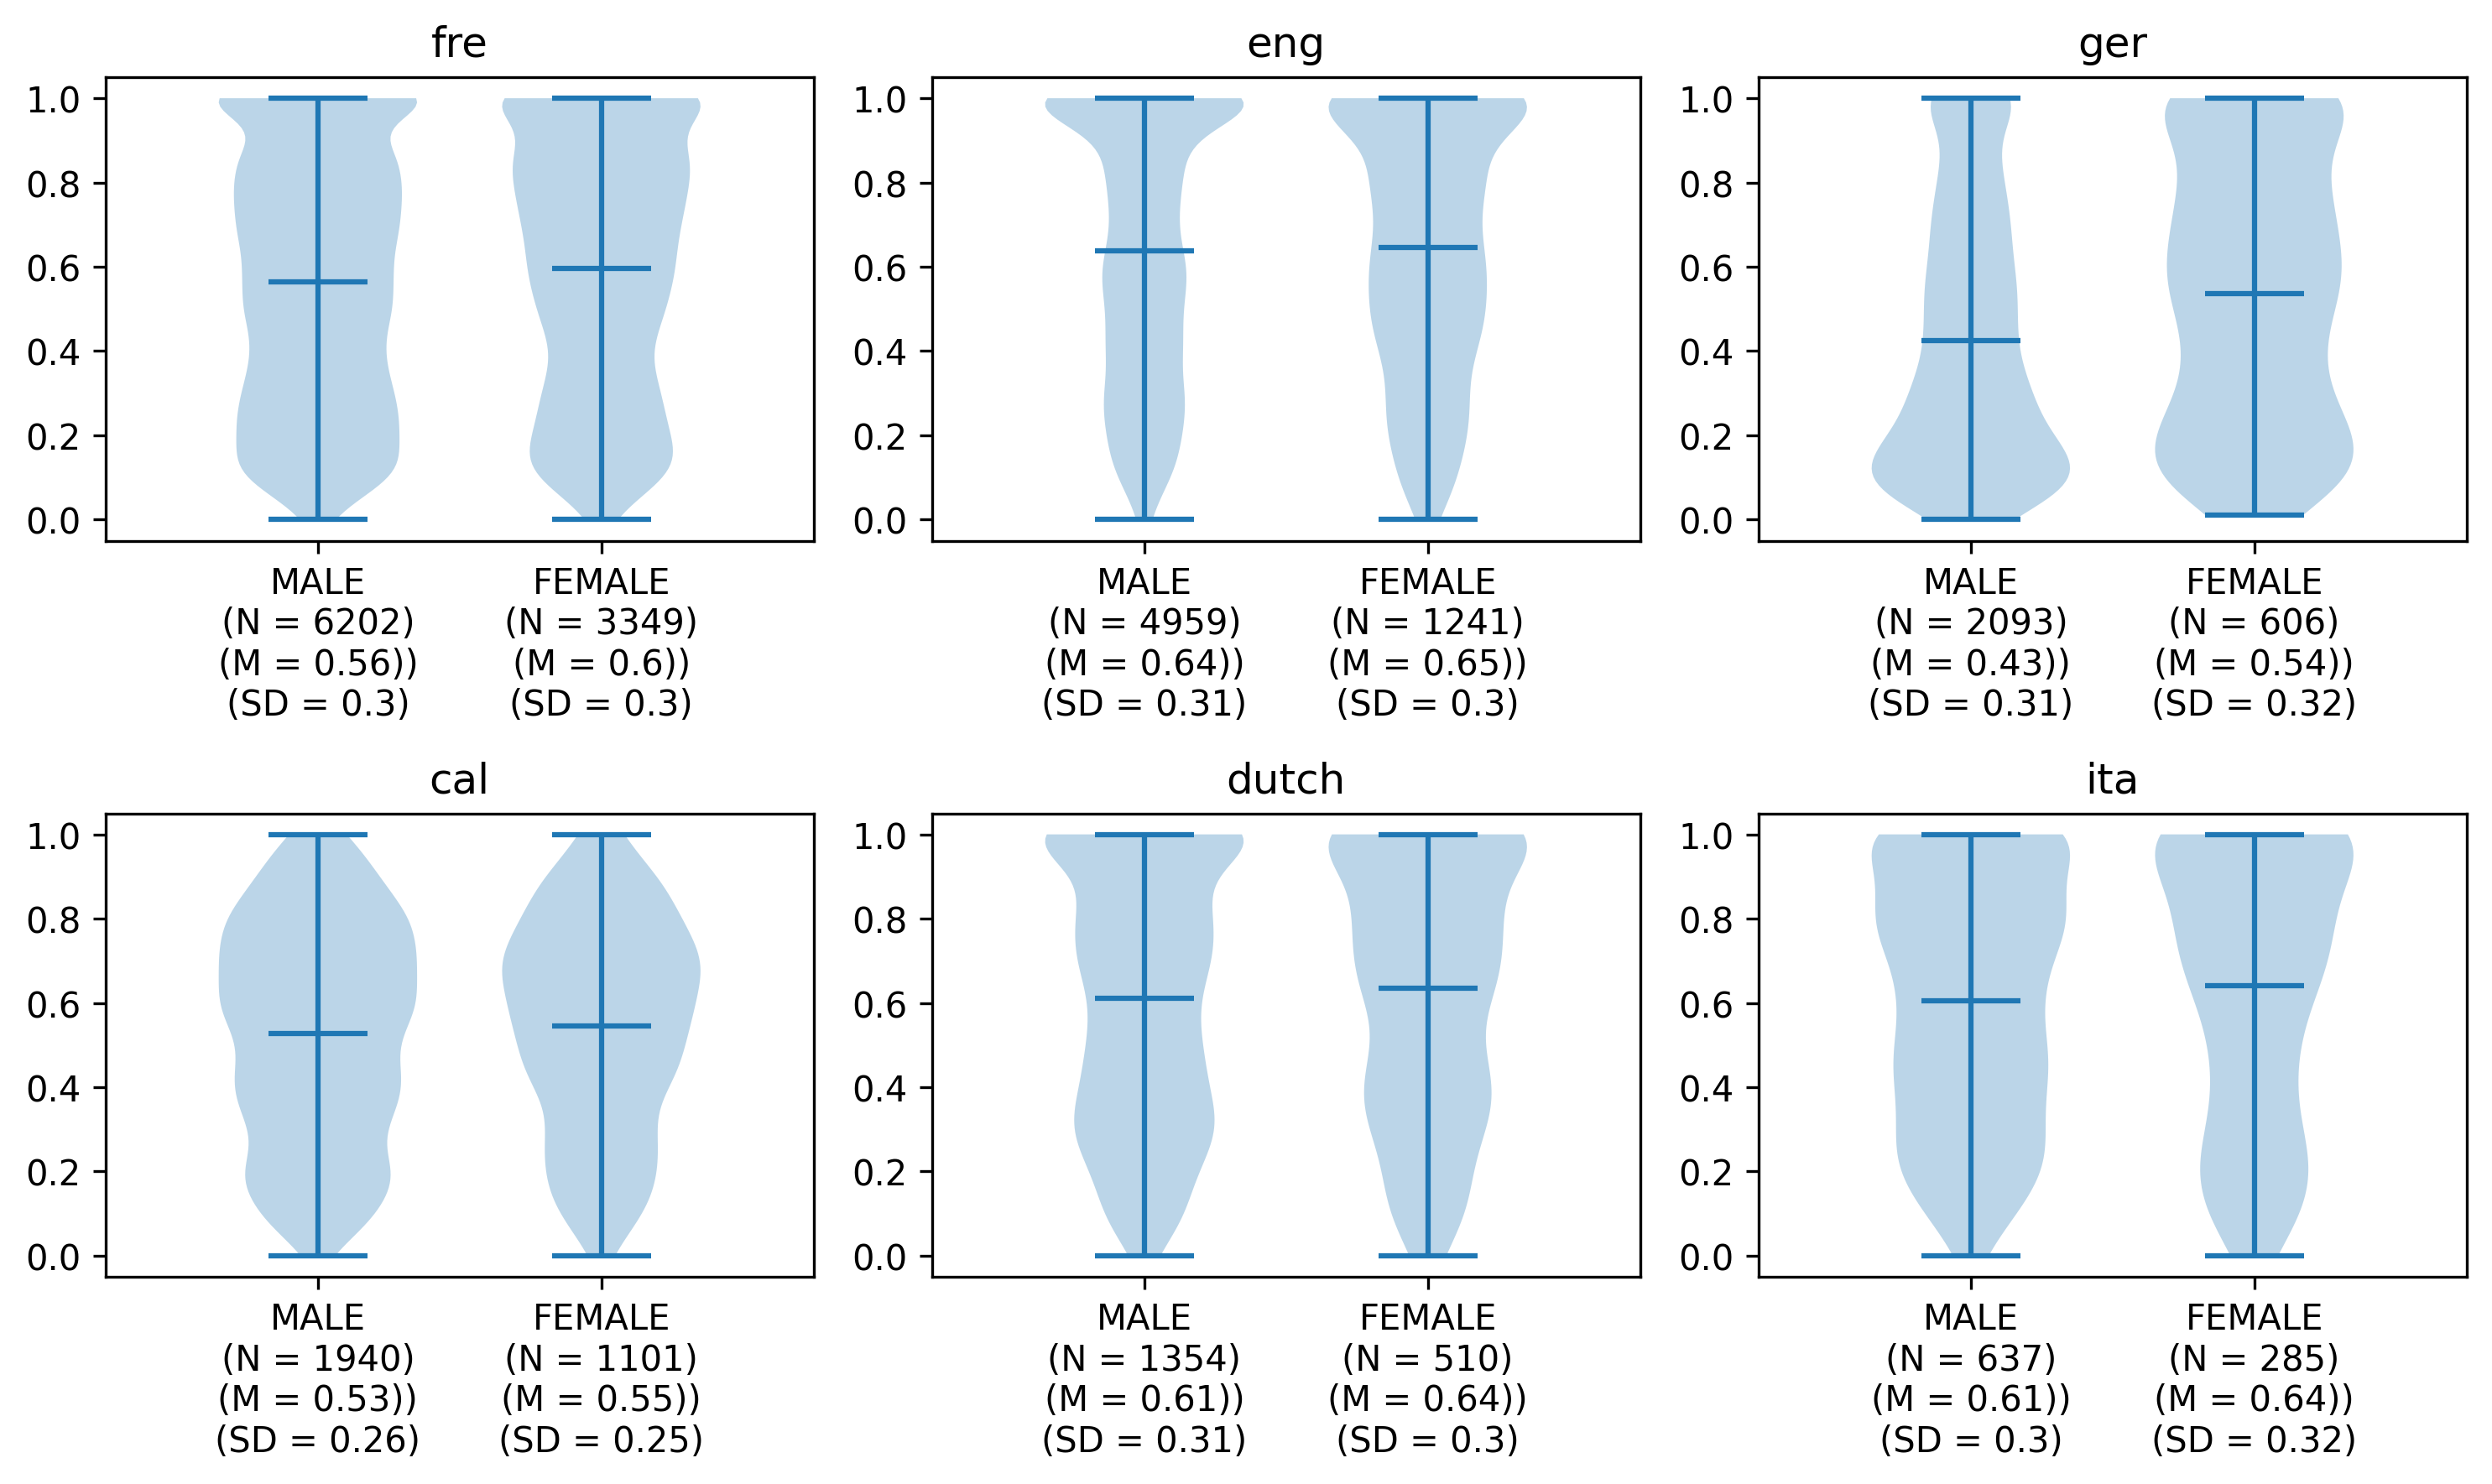

In [57]:
fig = plt.figure(figsize=(3,4), dpi=300)

independent_var = 'degree (rel)'

dataframes = [fre_character_data, eng_character_data, ger_character_data, cal_character_data, dutch_character_data, ita_character_data]
corpora = ["fre", "eng", "ger", "cal", "dutch", "ita"]

def set_axis_style(ax, dataframe, labels):
    labels = [('MALE' + '\n(N = ' + str(round(len(dataframe[dataframe.gender =="MALE"][independent_var]))) + ')\n(M = ' + str(round(dataframe[dataframe.gender == "MALE"][independent_var].mean(),2)) + ')'+ ')\n(SD = ' + str(round(dataframe[dataframe.gender == "MALE"][independent_var].std(),2)) + ')'),
              ('FEMALE' + '\n(N = ' + str(round(len(dataframe[dataframe.gender =="FEMALE"][independent_var]))) + ')\n(M = ' + str(round(dataframe[dataframe.gender == "FEMALE"][independent_var].mean(),2)) + ')'+ ')\n(SD = ' + str(round(dataframe[dataframe.gender == "FEMALE"][independent_var].std(),2)) + ')')
              ]
    ax.set_xticks([1,2], labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    #ax.set_xlabel('Gender')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 6), dpi=300)

#fig, axes = plt.subplots()

#axes[0].violinplot(dataset = [dataframe[dataframe.gender == 'MALE'][independent_var].values,
#                            dataframe[dataframe.gender == 'FEMALE'][independent_var].values,], showmeans=True, widths=0.7 )

#

labels = ['MALE', 'FEMALE']
df_counter = 0

for ax in axes.flatten():
    dataframe = dataframes[df_counter]
    ax.violinplot(dataset = [dataframe[dataframe.gender == 'MALE'][independent_var].values,
                            dataframe[dataframe.gender == 'FEMALE'][independent_var].values,], showmeans=True, widths=0.7 )
    ax.set_title(corpora[df_counter])
    df_counter +=1
    set_axis_style(ax, dataframe, labels)



'''
for ax in [axes]:
    set_axis_style(ax, labels)
'''
#axes.set_title('Degree centrality by gender')
#axes.yaxis.grid(True)
#axes.set_xticks("")
#axes.set_xlabel('Scenario')
#axes.set_ylabel('% of all characters in the play')

fig.tight_layout()
#plt.show()
plt.savefig(home_dir + "Figuren/" + "violinplot_male_female_centrality.png", bbox_inches='tight') #uncomment to save the image



<Figure size 1800x1800 with 0 Axes>

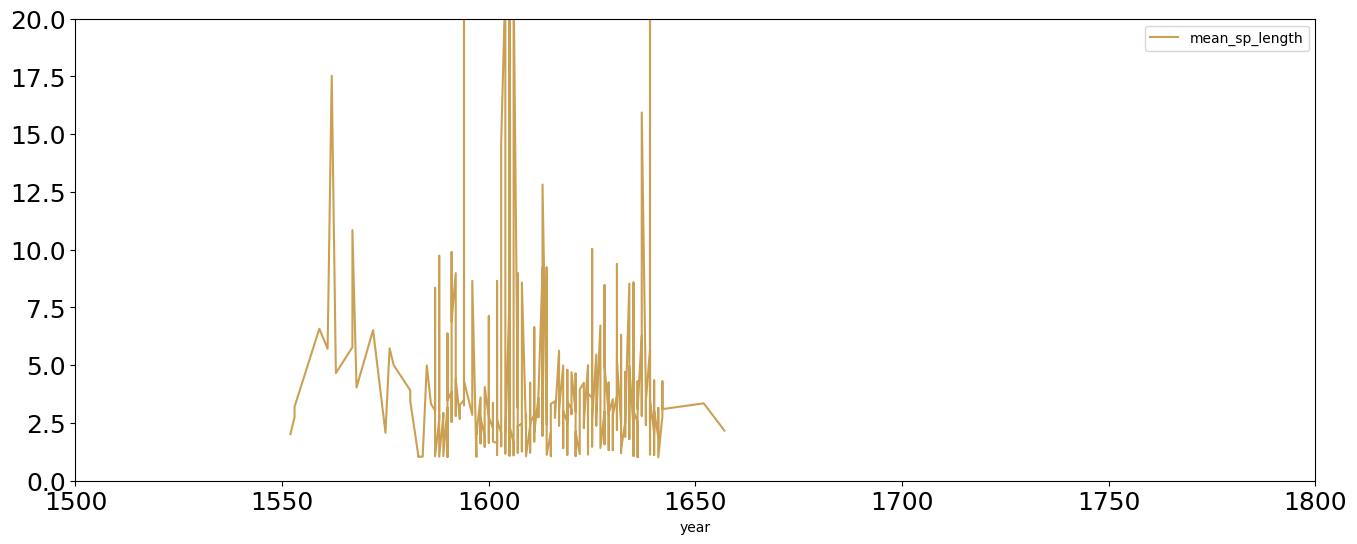

In [90]:
variable1 = "mean_sp_length"
#variable2 = "%_female_chars"

fig = plt.figure(figsize=(6,6), dpi=300)
line_chart = eng_play_data.sort_values('year').plot(x='year', y=[variable1], figsize=(16,6), color="#cba052", ylim=(0,20), xlim=(1500,1800), fontsize=18)

plt.show()
#plt.axhline(y = 0.5, color = 'grey', label = '50 %', linestyle="dotted")
#plt.axvline(x = 101, color = 'darkred', label = '1655', linestyle="dashed")
#plt.savefig(output_folder + "linechart_" + variable +".png", bbox_inches='tight') #uncomment to save the image